In [1]:
import pandas as pd
import json
import numpy as np

In [2]:
df = pd.read_json("amz.json")
df

,product_name,product_price,product_rating,product_image
0,[24-Piece Black Silverware Set with Steak Kniv...,$21.99,No Rating,[https://m.media-amazon.com/images/I/71vZ7TGZW...
1,[Martha Stewart 14 Piece High Carbon Stainless...,$59.99,No Rating,[https://m.media-amazon.com/images/I/71SDcteFT...
2,[Euro Ceramica Zanzibar Collection 16 Piece Di...,$75.23,No Rating,[https://m.media-amazon.com/images/I/91YXK04MZ...
3,[VECELO 3 Piece Small Round Dining Table Set f...,$69.99,No Rating,[https://m.media-amazon.com/images/I/71mpl-CsF...
4,"[VECELO Small Round Dining Table Set for 2, Wo...",$104.39,No Rating,[https://m.media-amazon.com/images/I/716RwmEj8...
...,...,...,...,...
1827,"[OTHWAY Square Shower Mat, 27""*27""Extra Large ...",$26.99,No Rating,[https://m.media-amazon.com/images/I/81Goea9BT...
1828,"[WBTEER 9Pcs Laundry Bags Mesh Wash Bags, Ling...",$9.99,No Rating,[https://m.media-amazon.com/images/I/81iFkWAmZ...
1829,"[57PCS Prizes for Kids Bulk Toys, Goodie Bags ...",$12.99,No Rating,[https://m.media-amazon.com/images/I/816LEZLrL...
1830,[Cooling Pillows Queen Size Set of 2 - Adjusta...,$34.99,No Rating,[https://m.media-amazon.com/images/I/818Z9F8Y2...


In [3]:
df["product_name"] = df["product_name"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else (x if isinstance(x, str) else "")
)

In [4]:
df["product_name"]

0       24-Piece Black Silverware Set with Steak Knive...
1       Martha Stewart 14 Piece High Carbon Stainless ...
2       Euro Ceramica Zanzibar Collection 16 Piece Din...
3       VECELO 3 Piece Small Round Dining Table Set fo...
4       VECELO Small Round Dining Table Set for 2, Woo...
                              ...                        
1827    OTHWAY Square Shower Mat, 27"*27"Extra Large S...
1828    WBTEER 9Pcs Laundry Bags Mesh Wash Bags, Linge...
1829    57PCS Prizes for Kids Bulk Toys, Goodie Bags f...
1830    Cooling Pillows Queen Size Set of 2 - Adjustab...
1831                                                     
Name: product_name, Length: 1832, dtype: object

In [5]:
def clean_price(x):
    # Convert to string
    x = str(x).strip()
    
    # Remove dollar signs and commas
    x = x.replace("$", "").replace(",", "")
        
    # Handle single number
    try:
        return float(x)
    except:
        return None  # if cannot convert

# Apply to column
df["product_price"] = df["product_price"].apply(clean_price)

In [6]:
df[df.isna().any(axis=1)][["product_name", "product_price", "product_rating", "product_image"]]


,product_name,product_price,product_rating,product_image
24,,NaN,No Rating,[]
73,,NaN,No Rating,[]
98,,NaN,No Rating,[]
123,,NaN,No Rating,[]
162,,NaN,No Rating,[]
...,...,...,...,...
1707,,NaN,No Rating,[]
1756,,NaN,No Rating,[]
1781,,NaN,No Rating,[]
1806,,NaN,No Rating,[]


In [7]:
df = df.dropna()

In [8]:
df["product_price"]

0        21.99
1        59.99
2        75.23
3        69.99
4       104.39
         ...  
1826     79.99
1827     26.99
1828      9.99
1829     12.99
1830     34.99
Name: product_price, Length: 1765, dtype: float64

In [9]:
df.isna().sum()

product_name      0
product_price     0
product_rating    0
product_image     0
dtype: int64

In [10]:
df

,product_name,product_price,product_rating,product_image
0,24-Piece Black Silverware Set with Steak Knive...,21.99,No Rating,[https://m.media-amazon.com/images/I/71vZ7TGZW...
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,No Rating,[https://m.media-amazon.com/images/I/71SDcteFT...
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,No Rating,[https://m.media-amazon.com/images/I/91YXK04MZ...
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,No Rating,[https://m.media-amazon.com/images/I/71mpl-CsF...
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,No Rating,[https://m.media-amazon.com/images/I/716RwmEj8...
...,...,...,...,...
1826,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,No Rating,[https://m.media-amazon.com/images/I/71zY3owqe...
1827,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,No Rating,[https://m.media-amazon.com/images/I/81Goea9BT...
1828,"WBTEER 9Pcs Laundry Bags Mesh Wash Bags, Linge...",9.99,No Rating,[https://m.media-amazon.com/images/I/81iFkWAmZ...
1829,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,No Rating,[https://m.media-amazon.com/images/I/816LEZLrL...


In [11]:
filtered = df[df["product_rating"] != "No Rating"]
filtered

,product_name,product_price,product_rating,product_image
74,"[6 Pack] Salad Dressing Container To Go, 1.6 o...",8.99,[4.8],[https://m.media-amazon.com/images/I/61e4L8ouG...
76,"Itopor® Lunch Box,Natural Wheat Fiber Material...",11.99,[4.6],[https://m.media-amazon.com/images/I/81SEJRqbd...
77,"Fibevon Fairy Lights Battery Operated, 12-Pack...",7.99,[4.5],[https://m.media-amazon.com/images/I/81FN+48sz...
78,Teivio 5 Gallon 100 Counts Strong Trash Bags G...,8.49,[4.6],[https://m.media-amazon.com/images/I/617JCJ1GX...
79,"Electric Can Opener, One-Touch Can Opener Elec...",25.99,[4.8],[https://m.media-amazon.com/images/I/71PxGGW7m...
...,...,...,...,...
1702,"JELLYSUB 20-Hooks, 24-Strips, Clear Small Wire...",13.99,[4.0],[https://m.media-amazon.com/images/I/619iubG1G...
1703,Perlegear UL-Listed Full Motion TV Wall Mount ...,73.99,[4.8],[https://m.media-amazon.com/images/I/61FAu7LfW...
1704,Fixwal Round Side Table with Fabric Storage Ba...,27.99,[4.0],[https://m.media-amazon.com/images/I/71T8C2dCW...
1705,Mojoker 2 Pcs White Skinny Tumbler Lid Replace...,9.99,[4.4],[https://m.media-amazon.com/images/I/71Q3aGrLT...


In [12]:
# Keep original data safe
df["product_rating_1"] = df["product_rating"].copy()


C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\2967011142.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["product_rating_1"] = df["product_rating"].copy()


In [13]:
def extract_rating(val):
    if isinstance(val, list) and len(val) > 0:
        # Take first element
        v = val[0]
        if v == "No Rating":
            return np.nan
        else:
            try:
                return float(v)
            except:
                return np.nan
    elif val == "No Rating":
        return np.nan
    else:
        try:
            return float(val)
        except:
            return np.nan

df["product_clean_rated"] = df["product_rating_1"].apply(extract_rating)


C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\2046353260.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["product_clean_rated"] = df["product_rating_1"].apply(extract_rating)


In [14]:
df['product_clean_rated'].head(75)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
71    NaN
72    NaN
74    4.8
75    NaN
76    4.6
Name: product_clean_rated, Length: 75, dtype: float64

In [15]:
median_value = df["product_clean_rated"].median()
# print("Median rating:", median_value)

df["product_clean_rated"].fillna(median_value, inplace=True)


C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\3589663215.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["product_clean_rated"].fillna(median_value, inplace=True)
C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\3589663215.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["product_clean_rated"].fillna(median_value, inpla

In [16]:
df["product_clean_rated"]

0       4.6
1       4.6
2       4.6
3       4.6
4       4.6
       ... 
1826    4.6
1827    4.6
1828    4.6
1829    4.6
1830    4.6
Name: product_clean_rated, Length: 1765, dtype: float64

In [17]:
df

,product_name,product_price,product_rating,product_image,product_rating_1,product_clean_rated
0,24-Piece Black Silverware Set with Steak Knive...,21.99,No Rating,[https://m.media-amazon.com/images/I/71vZ7TGZW...,No Rating,4.6
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,No Rating,[https://m.media-amazon.com/images/I/71SDcteFT...,No Rating,4.6
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,No Rating,[https://m.media-amazon.com/images/I/91YXK04MZ...,No Rating,4.6
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,No Rating,[https://m.media-amazon.com/images/I/71mpl-CsF...,No Rating,4.6
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,No Rating,[https://m.media-amazon.com/images/I/716RwmEj8...,No Rating,4.6
...,...,...,...,...,...,...
1826,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,No Rating,[https://m.media-amazon.com/images/I/71zY3owqe...,No Rating,4.6
1827,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,No Rating,[https://m.media-amazon.com/images/I/81Goea9BT...,No Rating,4.6
1828,"WBTEER 9Pcs Laundry Bags Mesh Wash Bags, Linge...",9.99,No Rating,[https://m.media-amazon.com/images/I/81iFkWAmZ...,No Rating,4.6
1829,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,No Rating,[https://m.media-amazon.com/images/I/816LEZLrL...,No Rating,4.6


In [18]:
df[["product_name", "product_clean_rated", "product_price", "product_image"]].head(10)


,product_name,product_clean_rated,product_price,product_image
0,24-Piece Black Silverware Set with Steak Knive...,4.6,21.99,[https://m.media-amazon.com/images/I/71vZ7TGZW...
1,Martha Stewart 14 Piece High Carbon Stainless ...,4.6,59.99,[https://m.media-amazon.com/images/I/71SDcteFT...
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,4.6,75.23,[https://m.media-amazon.com/images/I/91YXK04MZ...
3,VECELO 3 Piece Small Round Dining Table Set fo...,4.6,69.99,[https://m.media-amazon.com/images/I/71mpl-CsF...
4,"VECELO Small Round Dining Table Set for 2, Woo...",4.6,104.39,[https://m.media-amazon.com/images/I/716RwmEj8...
5,VECELO 3-Piece Dining Room Wooden Kitchen Tabl...,4.6,90.44,[https://m.media-amazon.com/images/I/818cQKFEu...
6,Amazon Basics Basket Coffee Filters for 8-12 C...,4.6,1.78,[https://m.media-amazon.com/images/I/61LlOOBcy...
7,"Amazon Basics Everyday Paper Plates, 9 Inch, D...",4.6,16.15,[https://m.media-amazon.com/images/I/71CyDBWhQ...
8,"EWFEN Burger Press, 7"" Round & 8.2""X4.3"" Recta...",4.6,26.99,[https://m.media-amazon.com/images/I/81gMnns5s...
9,"Supmedic Nitrile Exam Glove, 3.5 mil Blue Disp...",4.6,7.98,[https://m.media-amazon.com/images/I/8118Jz4ns...


In [19]:
df["product_rating"] = df["product_clean_rated"].copy()
df['product_rating'].head(5)


C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\2507291352.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["product_rating"] = df["product_clean_rated"].copy()


0    4.6
1    4.6
2    4.6
3    4.6
4    4.6
Name: product_rating, dtype: float64

In [20]:
df

,product_name,product_price,product_rating,product_image,product_rating_1,product_clean_rated
0,24-Piece Black Silverware Set with Steak Knive...,21.99,4.6,[https://m.media-amazon.com/images/I/71vZ7TGZW...,No Rating,4.6
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,4.6,[https://m.media-amazon.com/images/I/71SDcteFT...,No Rating,4.6
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,4.6,[https://m.media-amazon.com/images/I/91YXK04MZ...,No Rating,4.6
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,4.6,[https://m.media-amazon.com/images/I/71mpl-CsF...,No Rating,4.6
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,4.6,[https://m.media-amazon.com/images/I/716RwmEj8...,No Rating,4.6
...,...,...,...,...,...,...
1826,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,4.6,[https://m.media-amazon.com/images/I/71zY3owqe...,No Rating,4.6
1827,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,4.6,[https://m.media-amazon.com/images/I/81Goea9BT...,No Rating,4.6
1828,"WBTEER 9Pcs Laundry Bags Mesh Wash Bags, Linge...",9.99,4.6,[https://m.media-amazon.com/images/I/81iFkWAmZ...,No Rating,4.6
1829,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,4.6,[https://m.media-amazon.com/images/I/816LEZLrL...,No Rating,4.6


In [21]:
df.drop(columns=["product_rating_1","product_clean_rated"], inplace = True)			

C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\2729650761.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["product_rating_1","product_clean_rated"], inplace = True)


In [22]:
image_backup = df["product_image"].copy()

In [23]:
df.drop(columns=["product_image"],inplace = True)

C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\2401371667.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["product_image"],inplace = True)


In [24]:
df

,product_name,product_price,product_rating
0,24-Piece Black Silverware Set with Steak Knive...,21.99,4.6
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,4.6
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,4.6
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,4.6
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,4.6
...,...,...,...
1826,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,4.6
1827,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,4.6
1828,"WBTEER 9Pcs Laundry Bags Mesh Wash Bags, Linge...",9.99,4.6
1829,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,4.6


In [25]:
df.isnull().sum()

product_name      0
product_price     0
product_rating    0
dtype: int64

In [26]:
df.dtypes

product_name       object
product_price     float64
product_rating    float64
dtype: object

In [27]:
df.duplicated().sum()

np.int64(321)

In [28]:
df[df['product_price'] <= 0]

,product_name,product_price,product_rating


In [29]:
df['product_price'].mean()

np.float64(39.101580736543916)

In [30]:
df[df.duplicated()]

,product_name,product_price,product_rating
25,Air Fryer Liners Disposable 100pcs Air Fryer P...,9.99,4.6
29,Combustion Predictive Thermometer & Display — ...,159.99,4.6
33,KITEXPERT Pepper Grinder - Chunky Glass Pepper...,5.99,4.6
56,Shatter Resistant Pink Glass Straws - 8 Pack o...,11.99,4.6
58,CherHome Silverware Organizer with Cutlery Ico...,10.70,4.6
...,...,...,...
1811,"12 PCS Fall Tiered Tray Decor, Gnomes Plush wi...",16.99,4.6
1816,Over the Door Organizer Storage - Zippered 6 S...,29.99,4.6
1818,Lorfancy 72 Pcs Ninja Party Favors Supplies Ki...,21.98,4.6
1825,Morfone White Noise Machine Baby with Voice Re...,19.59,4.6


In [31]:
duplicates_grouped = df[df.duplicated(subset=['product_name'], keep=False)] \
                        .sort_values(by='product_name')

duplicates_grouped

,product_name,product_price,product_rating
1489,"12 PCS Fall Tiered Tray Decor, Gnomes Plush wi...",16.99,4.6
1811,"12 PCS Fall Tiered Tray Decor, Gnomes Plush wi...",16.99,4.6
591,"12 Pack Drawer Organizers for Clothing, Foldab...",25.99,4.6
321,"12 Pack Drawer Organizers for Clothing, Foldab...",25.99,4.6
67,"12 Pack Kitchen Cloth, Dish Towels Super Absor...",4.99,4.6
...,...,...,...
1758,"yescool Weighted Blanket Kids 5 Pounds (36""x48...",17.99,4.6
683,"yescool Weighted Blanket Kids 5 Pounds (36""x48...",17.99,4.6
339,"yescool Weighted Blanket Kids 5 Pounds (36""x48...",17.99,4.6
1258,（8 Bags） Vacuum Cleaner Bags for XL Oreck Type...,11.99,5.0


In [32]:
df_clean = df.drop_duplicates(subset=['product_name'])

In [33]:
df_clean['product_name'].duplicated().sum()

np.int64(0)

In [34]:
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (1765, 3)
After: (1339, 3)


In [35]:
df_clean

,product_name,product_price,product_rating
0,24-Piece Black Silverware Set with Steak Knive...,21.99,4.6
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,4.6
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,4.6
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,4.6
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,4.6
...,...,...,...
1824,Wall Sconces Set of Two Battery Operated Wall ...,27.97,4.6
1826,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,4.6
1827,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,4.6
1829,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,4.6


In [36]:
df_clean[df_clean.duplicated(subset=['product_name'], keep=False)]

,product_name,product_price,product_rating


In [37]:
df_clean.isnull().sum()

product_name      0
product_price     0
product_rating    0
dtype: int64

In [38]:
df_clean['product_rating'].value_counts().head(10)

product_rating
4.6    1140
4.7      33
5.0      32
4.8      29
4.4      23
4.5      20
4.3      17
4.9      15
4.2       6
4.0       6
Name: count, dtype: int64

In [39]:
df_clean.dtypes

product_name       object
product_price     float64
product_rating    float64
dtype: object

In [40]:
df_clean[df_clean['product_price'] <= 0]

,product_name,product_price,product_rating


In [41]:
df_clean['product_price'].describe()

count    1339.000000
mean       36.326766
std       102.947085
min         1.780000
25%        10.995000
50%        18.990000
75%        29.990000
max      1669.990000
Name: product_price, dtype: float64

In [42]:
df_clean.sort_values('product_price', ascending=False).head(10)

,product_name,product_price,product_rating
1544,LebenLiebe Outdoor Patio Dining Set of 7 with ...,1669.99,4.6
161,ZckyCine Modern mid-Century Dining Table Dinin...,1259.00,4.6
146,"jiexi 71"" Extendable Dining Table Set, Kitchen...",1099.99,4.6
1522,"jiexi Extendable Dining Table Set for 6-8, Rec...",1099.99,4.6
145,ZckyCine 6-8 People Modern Dining Table Rectan...,1069.00,4.6
1244,Zerifevni Dining Table Mid-Century Kitchen Tab...,999.99,4.6
1219,"Zerifevni Dining Table Set for 6, Modern White...",928.00,4.6
1231,ZckyCine Modern Mid-Century Dining Table Set f...,919.00,4.6
1686,Ganiza Cordless Vacuum Cleaner- 𝟐𝟖𝐊𝐩𝐚 Powerful...,799.99,4.7
1621,"Guyii Dining Table Set with 4 Chairs, Modern K...",761.17,4.6


In [43]:
df_clean

,product_name,product_price,product_rating
0,24-Piece Black Silverware Set with Steak Knive...,21.99,4.6
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,4.6
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,4.6
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,4.6
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,4.6
...,...,...,...
1824,Wall Sconces Set of Two Battery Operated Wall ...,27.97,4.6
1826,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,4.6
1827,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,4.6
1829,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,4.6


In [44]:
df_clean.shape

(1339, 3)

In [45]:
df_clean.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1819, 1820, 1821, 1822, 1823, 1824, 1826, 1827, 1829, 1830],
      dtype='int64', length=1339)

In [46]:
df_clean = df_clean.reset_index(drop=True)

In [47]:
df_clean['product_id'] = df_clean.index

In [48]:
df_clean.index

RangeIndex(start=0, stop=1339, step=1)

In [49]:
df_clean

,product_name,product_price,product_rating,product_id
0,24-Piece Black Silverware Set with Steak Knive...,21.99,4.6,0
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,4.6,1
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,4.6,2
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,4.6,3
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,4.6,4
...,...,...,...,...
1334,Wall Sconces Set of Two Battery Operated Wall ...,27.97,4.6,1334
1335,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,4.6,1335
1336,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,4.6,1336
1337,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,4.6,1337


In [50]:
df_clean = df_clean[['product_name', 'product_price', 'product_rating']]

In [51]:
df_clean

,product_name,product_price,product_rating
0,24-Piece Black Silverware Set with Steak Knive...,21.99,4.6
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,4.6
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,4.6
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,4.6
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,4.6
...,...,...,...
1334,Wall Sconces Set of Two Battery Operated Wall ...,27.97,4.6
1335,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,4.6
1336,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,4.6
1337,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,4.6


In [52]:
df_clean

,product_name,product_price,product_rating
0,24-Piece Black Silverware Set with Steak Knive...,21.99,4.6
1,Martha Stewart 14 Piece High Carbon Stainless ...,59.99,4.6
2,Euro Ceramica Zanzibar Collection 16 Piece Din...,75.23,4.6
3,VECELO 3 Piece Small Round Dining Table Set fo...,69.99,4.6
4,"VECELO Small Round Dining Table Set for 2, Woo...",104.39,4.6
...,...,...,...
1334,Wall Sconces Set of Two Battery Operated Wall ...,27.97,4.6
1335,SUOCO SheetCube Bed Sheet Set Organizer 4 Pack...,79.99,4.6
1336,"OTHWAY Square Shower Mat, 27""*27""Extra Large S...",26.99,4.6
1337,"57PCS Prizes for Kids Bulk Toys, Goodie Bags f...",12.99,4.6


In [53]:
print(df_clean['product_rating'].value_counts())


product_rating
4.6    1140
4.7      33
5.0      32
4.8      29
4.4      23
4.5      20
4.3      17
4.9      15
4.2       6
4.0       6
3.9       4
4.1       4
3.5       2
3.0       2
3.6       2
3.4       1
3.7       1
1.0       1
3.8       1
Name: count, dtype: int64


In [54]:
df_clean.isnull().sum()

product_name      0
product_price     0
product_rating    0
dtype: int64

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
%pip install "setuptools<82.0.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df_clean, title="Amazon Product Data Report")

d:\Ibraheem Data\Projects\Amazon_data\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [58]:
# This saves the file to your 'Amazon_data' folder
html_report =profile.to_file("../yprofiling/Amazon_Product_Report.html")

d:\Ibraheem Data\Projects\Amazon_data\venv\Lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 204.34it/s]


# Univarite Analysis

In [59]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
product_price,1339.0,36.326766,102.947085,1.78,10.995,18.99,29.99,1669.99
product_rating,1339.0,4.592532,0.177184,1.00,4.600,4.60,4.60,5.00


In [60]:
    # Summay statistics
numeric_cols = ["product_price", "product_rating"]

summary = df_clean[numeric_cols].describe().T
summary['median'] = df_clean[numeric_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = df_clean[numeric_cols].skew()
print("Numeric Summay Statistics:\n")
summary


Numeric Summay Statistics:



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
product_price,1339.0,36.326766,102.947085,1.78,10.995,18.99,29.99,1669.99,18.99,18.995,9.525081
product_rating,1339.0,4.592532,0.177184,1.00,4.600,4.60,4.60,5.00,4.60,0.000,-8.481993


In [61]:
# Updated loop with the correct parameter
for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    
    # 1. Histogram (Frequency of prices)
    plt.subplot(1, 3, 1)
    sns.histplot(df_clean[col], kde=True, color='skyblue')
    plt.title(f'{col} Histogram')
    
    # 2. Boxplot (Best for spotting those crazy Amazon outliers)
    plt.subplot(1, 3, 2)
    sns.boxplot(x=df_clean[col], color='lightgreen')
    plt.title(f'{col} Boxplot')
    
    # 3. Density Plot (The "Fill" version)
    plt.subplot(1, 3, 3)
    sns.kdeplot(df_clean[col], fill=True, color='salmon') # Fix applied here
    plt.title(f'{col} Density Plot')
    
    plt.tight_layout()
    plt.show()

C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\3184846548.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\3184846548.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Bivariate Analysis


In [62]:
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Coorelation Heatmap')
plt.show()

#Pairwise scatter plots + regressionl lines

sns.pairplot(df_clean[numeric_cols], kind='reg', diag_kind = 'kde', corner = True, plot_kws= {'line_kws': {'color': 'red'}})
plt.suptitle('Scater and Regression lines between Numeric Variables', y= 1.02)
plt.show()

C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\3631017638.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\3631017638.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [63]:
# Create the log-transformed column
df_clean['log_product_price'] = np.log1p(df_clean['product_price'])

# Now, re-run your scatter plot using the NEW column
plt.figure(figsize=(8, 5))
sns.regplot(data=df_clean, x='log_product_price', y='product_rating', 
            line_kws={"color": "red"}, scatter_kws={'alpha':0.3})
plt.title('Rating vs. Log-Transformed Price')
plt.show()

C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\1134546653.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [64]:
df_clean['value_score'] = df_clean['product_rating'] / (df_clean['log_product_price'] + 1)
df_clean[['product_name', 'product_price', 'product_rating', 'value_score']].sort_values(by='value_score', ascending=False).head(10)

,product_name,product_price,product_rating,value_score
6,Amazon Basics Basket Coffee Filters for 8-12 C...,1.78,4.6,2.274468
365,"Halloween Decorations 3D Bats 96 Pcs, Hallowee...",2.99,4.6,1.929699
83,"Damp Duster Clean Sponge,Damp Duster for Car a...",2.99,4.4,1.845799
657,"Bounty Essentials Select-A-Size Paper Towels, ...",3.49,4.6,1.838637
10,Amazon Basics Number 4 Cone Coffee Filters for...,3.60,4.6,1.821020
286,"GYEKEHSN Metal Curtain Hooks for Drapes, Stain...",5.19,5.0,1.771206
404,Grihot air fryer liners silicone 2+1 Pack frye...,3.95,4.6,1.769648
337,"Halloween Bats Wall Decor, 80 Pcs 3D Plastic B...",3.99,4.6,1.764185
80,"Homradise Electric Milk Frother Handheld, Coff...",3.99,4.5,1.725833
94,5PCS Small Measuring Spoons Set - Cuttte Stain...,5.00,4.7,1.683526


In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select your features for Multivariate Analysis
features = ['log_product_price', 'product_rating', 'value_score']
X = df_clean[features]

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Clustering (Let's stick with 3 for now)
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

In [66]:
import seaborn as sns
sns.pairplot(df_clean, vars=features, hue='cluster', palette='viridis')
plt.show()

C:\Users\Mr Usman\AppData\Local\Temp\ipykernel_23600\28856401.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [67]:
# Calculate the average characteristics of each cluster
cluster_profile = df_clean.groupby('cluster')[['product_price', 'product_rating', 'value_score']].mean()
cluster_count = df_clean['cluster'].value_counts()

print("Cluster Profiles (Averages):")
print(cluster_profile)
print("\nNumber of products in each cluster:")
print(cluster_count)

Cluster Profiles (Averages):
         product_price  product_rating  value_score
cluster                                            
0            10.503923        4.620438     1.369252
1            27.427682        4.569385     1.072323
2           257.754783        4.602174     0.764780

Number of products in each cluster:
cluster
1    699
0    548
2     92
Name: count, dtype: int64


In [68]:
# Show top 5 'High Value' products
top_value_products = df_clean[df_clean['cluster'] == 0].sort_values(by='value_score', ascending=False).head(5)
print(top_value_products[['product_name', 'product_price', 'product_rating']])

                                          product_name  product_price  \
6    Amazon Basics Basket Coffee Filters for 8-12 C...           1.78   
365  Halloween Decorations 3D Bats 96 Pcs, Hallowee...           2.99   
83   Damp Duster Clean Sponge,Damp Duster for Car a...           2.99   
657  Bounty Essentials Select-A-Size Paper Towels, ...           3.49   
10   Amazon Basics Number 4 Cone Coffee Filters for...           3.60   

     product_rating  
6               4.6  
365             4.6  
83              4.4  
657             4.6  
10              4.6  


## Other Practices

<Axes: ylabel='product_price'>

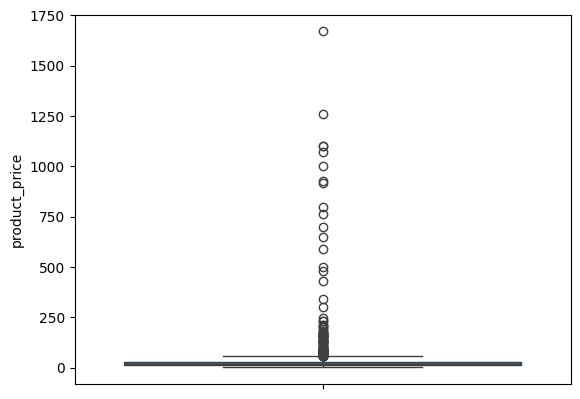

In [67]:
sns.boxplot(df_clean['product_price'])

In [75]:
df_clean['mean'] = np.mean(df_clean['product_price'])
df_clean['std'] =  np.std(df_clean['product_price'])

df_clean['z_score'] = (df_clean['product_price']-df_clean['mean'])/df_clean['std']

In [76]:
df_clean[['product_price', 'z_score', 'mean', 'std']]


,product_price,z_score,mean,std
0,21.99,-0.139315,36.326766,102.908636
1,59.99,0.229944,36.326766,102.908636
2,75.23,0.378037,36.326766,102.908636
3,69.99,0.327118,36.326766,102.908636
4,104.39,0.661395,36.326766,102.908636
...,...,...,...,...
1334,27.97,-0.081206,36.326766,102.908636
1335,79.99,0.424291,36.326766,102.908636
1336,26.99,-0.090729,36.326766,102.908636
1337,12.99,-0.226772,36.326766,102.908636


In [77]:
#Data with outliers
print('----------------------------------')
print(f"Here is the data with outliers \n {df_clean[['product_price', 'z_score', 'mean', 'std']]}")
print('----------------------------------')

----------------------------------
Here is the data with outliers 
       product_price   z_score       mean         std
0             21.99 -0.139315  36.326766  102.908636
1             59.99  0.229944  36.326766  102.908636
2             75.23  0.378037  36.326766  102.908636
3             69.99  0.327118  36.326766  102.908636
4            104.39  0.661395  36.326766  102.908636
...             ...       ...        ...         ...
1334          27.97 -0.081206  36.326766  102.908636
1335          79.99  0.424291  36.326766  102.908636
1336          26.99 -0.090729  36.326766  102.908636
1337          12.99 -0.226772  36.326766  102.908636
1338          34.99 -0.012990  36.326766  102.908636

[1339 rows x 4 columns]
----------------------------------


In [80]:
# Identify outliers using z-score threshold (e.g., 3)
print(f"Here are the outliers based on z-score threshold of 3: \n {df_clean[['product_price']][df_clean['z_score'] > 3]}")
print('----------------------------------')

Here are the outliers based on z-score threshold of 3: 
       product_price
107          649.99
109          479.15
121         1069.00
122         1099.99
136         1259.00
690          699.99
891          928.00
899          588.99
900          919.00
908          999.99
1103        1099.99
1116        1669.99
1176         761.17
1206         431.20
1227         799.99
1333         499.00
----------------------------------
